<a href="https://colab.research.google.com/github/YomnaHadad/MNIST---TensorFlow/blob/main/tf_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MNIST with TensorFlow

In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

In [ ]:
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)
# the next time u run this cell, the computer will fetch the data from the hard drive instead of downloading the data again
# as_supervised >> loads the data in 2-tuple structure [input, target]
# with_info     >> provides a tuple containing info about version, features and # of samples of the dataset

mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

# creating validation samples
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)

# test samples
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

# define a function to scale the pixel value to be btwn 0 and 1
def scale(image, label):
    image = tf.cast(image, tf.float32)
    image /= 255.
    return image, label

# apply the previous function to the data  (custom transformation usign map)
scaled_train_validation_data = mnist_train.map(scale)    # scale the whole training data
test_data = mnist_test.map(scale)

In [ ]:
######## shuffling the data
buffer_size = 10000
'''
enormous datasets can't be shuffled all at once
buffer_size = 1 >> no shuffling
            = num_samples >> shuffling happens at once
            = < num_samples >> we're optimizing the computational power

### there's a shuffling method exists we just needed to specify the buffer size
'''
shuffled_train_validation_data = scaled_train_validation_data.shuffle(buffer_size)

validation_data = shuffled_train_validation_data.take(num_validation_samples)
train_data = shuffled_train_validation_data.skip(num_validation_samples)

######## Combining a consecutive elements of a dataset into batches
batch_size = 100
train_data = train_data.batch(batch_size)

# we don't backpropagate in the validation datasets we don't need to batch as batching useful in updating weights once per batch so we take the data at once
# BUT, the model expects our validation set in batch form too
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

validation_inputs, validation_targets = next(iter(validation_data))

outline the model

In [ ]:
input_size = 784
output_size = 10

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape =(28,28,1)),
    tf.keras.layers.Dense(units=256, activation='relu'),
    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dense(output_size, activation='softmax')
])

objective function and optimization algorithm

- categorical_crossentropy >> expects that u've one-hot encoded the targets
- sparse_categorical_crossentropy >> applies one-hot encoding

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=["accuracy"])    # metrics can be recall or precision...

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,932 (495.83 KB)

 Trainable params: 42,310 (165.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 84,622 (330.56 KB)

Non-trainable params: 0 >> for finetunning

training then testing

In [ ]:
num_epochs = 5
model.fit(train_data, epochs= num_epochs, validation_data=(validation_inputs, validation_targets), verbose=2)

### Testing
test_loss, test_accuracy = model.evaluate(test_data)

Epoch 1/5
540/540 - 10s - 18ms/step - accuracy: 0.8784 - loss: 0.4155 - val_accuracy: 0.9342 - val_loss: 0.2116
Epoch 2/5
540/540 - 3s - 6ms/step - accuracy: 0.9468 - loss: 0.1788 - val_accuracy: 0.9563 - val_loss: 0.1516
Epoch 3/5
540/540 - 3s - 6ms/step - accuracy: 0.9592 - loss: 0.1367 - val_accuracy: 0.9623 - val_loss: 0.1289
Epoch 4/5
540/540 - 4s - 8ms/step - accuracy: 0.9656 - loss: 0.1158 - val_accuracy: 0.9662 - val_loss: 0.1117
Epoch 5/5
540/540 - 3s - 6ms/step - accuracy: 0.9704 - loss: 0.0987 - val_accuracy: 0.9713 - val_loss: 0.0986
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9655 - loss: 0.1104


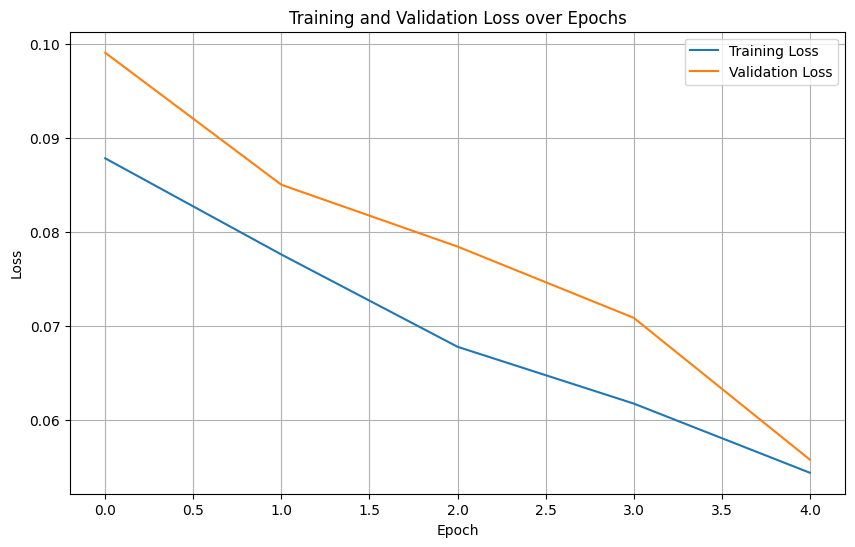

In [ ]:
import matplotlib.pyplot as plt

# Re-train the model to capture the history object
history = model.fit(train_data, epochs=num_epochs, validation_data=(validation_inputs, validation_targets), verbose=0)

# Plotting the loss and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

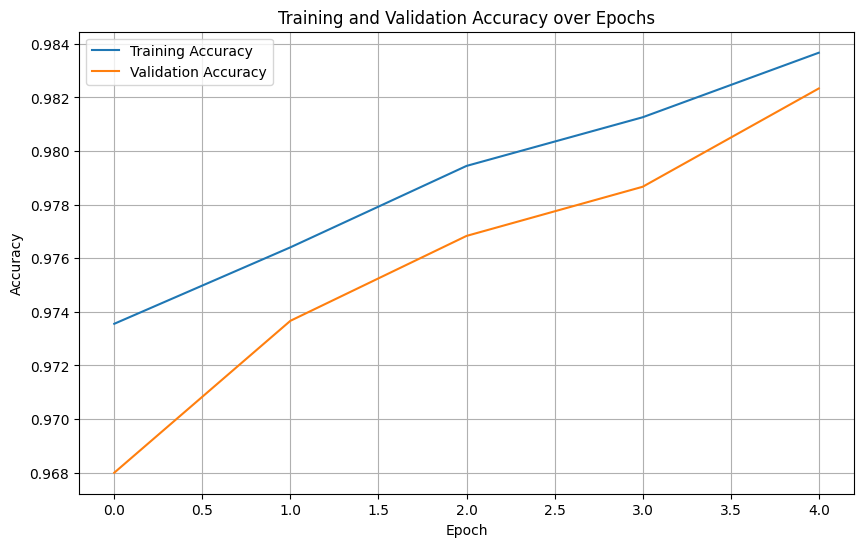

In [ ]:
import matplotlib.pyplot as plt

# Plotting the accuracy and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()